In [1]:
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#       jupytext_version: 1.19.1

#     language: python
#     name: python3
# ---

# 02 - Tiền xử lý ảnh + Ablation Study

**Mục tiêu:** Áp dụng đầy đủ 4 nhóm kỹ thuật tiền xử lý (Resize, Color Space, Normalization, Augmentation),
đo lường định lượng tác động bằng ablation study (k-NN), kiểm định thống kê.

**Dataset:** NWPU-RESISC45 - 45 lớp, 256×256 pixel.

## 0. Setup

In [2]:
import json
from pathlib import Path
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm
from scipy import stats
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')
plt.rcParams.update(
    {'figure.figsize': (12, 6), 'font.size': 11, 'figure.dpi': 100})
sns.set_style("whitegrid")


try:
    _SOURCE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    _SOURCE_DIR = Path.cwd().parent

_IMG_ROOT = _SOURCE_DIR / 'data' / 'raw' / 'image'
TRAIN_DIR = str(_IMG_ROOT / 'train')
OUTPUT_DIR = str(_SOURCE_DIR / 'data' / 'processed' / 'image')
os.makedirs(OUTPUT_DIR, exist_ok=True)
FIGURES_DIR = str(_SOURCE_DIR / 'outputs' / 'image')
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f"TRAIN_DIR   = {TRAIN_DIR}")
print(f"OUTPUT_DIR  = {OUTPUT_DIR}")
print(f"FIGURES_DIR = {FIGURES_DIR}")

# ── Chain check: đọc danh sách duplicate từ 01_EDA_image (nếu có) ──────────
_dup_csv = os.path.join(OUTPUT_DIR, 'duplicate_paths.csv')
if os.path.exists(_dup_csv):
    import pandas as _pd_chain
    EXCLUDED_PATHS = set(_pd_chain.read_csv(_dup_csv)['path'].tolist())
    print(
        f"[Chain 01→02] Loại trừ {len(EXCLUDED_PATHS)} ảnh duplicate khi load.")
else:
    EXCLUDED_PATHS = set()

classes = sorted(os.listdir(TRAIN_DIR))
print(f"Số lớp: {len(classes)}")

TRAIN_DIR   = d:\DataMining\DataPreprocessing\Source\data\raw\image\train
OUTPUT_DIR  = d:\DataMining\DataPreprocessing\Source\data\processed\image
FIGURES_DIR = d:\DataMining\DataPreprocessing\Source\outputs\image
[Chain 01→02] Loại trừ 7 ảnh duplicate khi load.
Số lớp: 45


In [3]:
def load_sample(n_per_class=20, target_classes=None, seed=42):
    """Load ảnh mẫu, tự động loại trừ EXCLUDED_PATHS (từ 01_EDA duplicate list)."""
    np.random.seed(seed)
    target = target_classes or classes
    samples = []
    for cls in target:
        paths = glob.glob(os.path.join(TRAIN_DIR, cls, "*.jpg"))
        # Loại trừ ảnh đã được đánh dấu là duplicate bởi 01_EDA
        paths = [p for p in paths if p not in EXCLUDED_PATHS]
        chosen = np.random.choice(paths, min(
            n_per_class, len(paths)), replace=False)
        for p in chosen:
            img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
            samples.append((img, cls))
    return samples

### Cấu hình sampling cho ablation study

Dùng toàn bộ 45 lớp để kết quả không bị bias.
Giới hạn số ảnh/lớp để thời gian chạy hợp lý.

In [4]:
quick_brightness = {}
for cls in classes:
    paths = glob.glob(os.path.join(TRAIN_DIR, cls, "*.jpg"))[:5]
    vals = [cv2.imread(p).mean() for p in paths]
    quick_brightness[cls] = np.mean(vals)

sorted_by_bright = sorted(quick_brightness, key=quick_brightness.get)
n = len(sorted_by_bright)
indices_10 = np.linspace(0, n - 1, 10, dtype=int)
SAMPLE_CLASSES = [sorted_by_bright[i] for i in indices_10]

for cls in SAMPLE_CLASSES:
    print(f"  {cls}: brightness = {quick_brightness[cls]:.1f}")

  forest: brightness = 49.6
  meadow: brightness = 71.0
  lake: brightness = 75.5
  palace: brightness = 82.0
  island: brightness = 86.6
  storage_tank: brightness = 88.6
  mobile_home_park: brightness = 102.1
  beach: brightness = 108.9
  thermal_power_station: brightness = 117.0
  desert: brightness = 176.9


---
## 1. Resize - Ablation Study (SSIM / PSNR)

**Lý thuyết:**

Resize giảm chiều không gian ảnh từ $H_{\text{orig}} \times W_{\text{orig}}$ về kích thước nhỏ hơn.
Đo mất mát thông tin bằng cách **resize xuống rồi resize lên lại** cự gốc, sau đó tính 2 metrics:

**SSIM (Structural Similarity Index Measure)** — đo sự tương đồng cấu trúc gitta 2 ảnh:

$$\text{SSIM}(x,y) = \frac{(2\mu_x\mu_y + C_1)(2\sigma_{xy} + C_2)}{(\mu_x^2+\mu_y^2+C_1)(\sigma_x^2+\sigma_y^2+C_2)}$$

- $\mu_x, \mu_y$: mean của patch $x, y$; $\sigma_x^2, \sigma_y^2$: variance; $\sigma_{xy}$: covariance
- $C_1 = (k_1 L)^2,\ C_2 = (k_2 L)^2$ với $k_1=0.01,\ k_2=0.03,\ L=255$ (hằng số ổn định)
- $\text{SSIM} \in [-1, 1]$; giá trị 1 = hai ảnh giống hệt nhau

**PSNR (Peak Signal-to-Noise Ratio)** — đo tỷ lệ tín hiệu/nhiễu (dB):

$$\text{PSNR} = 10\log_{10}\!\left(\frac{255^2}{\text{MSE}}\right), \quad
\text{MSE} = \frac{1}{HW}\sum_{i,j}(I_{ij}-\hat{I}_{ij})^2$$

- PSNR cao hơn ⇒ chất lượng tốt hơn ($> 30$ dB thuờng chấp nhận được)
- SSIM nhạy hơn PSNR với các lỗi cấu trúc (texture loss, blurring)

- $H_0$: Chất lượng ảnh (SSIM) không khác biệt giữa 3 kích thước resize
- $H_1$: Ít nhất 1 kích thước cho SSIM khác biệt

In [5]:
RESIZE_DIMS = [(32, 32), (64, 64), (128, 128), (224, 224)]
samples = load_sample(n_per_class=30, target_classes=SAMPLE_CLASSES)
print(f"Sample: {len(samples)} ảnh từ {len(SAMPLE_CLASSES)} lớp")

Sample: 300 ảnh từ 10 lớp


In [6]:
results_resize = []
for img_orig, cls in tqdm(samples, desc="Resize ablation"):
    for (h, w) in RESIZE_DIMS:
        resized = cv2.resize(img_orig, (w, h), interpolation=cv2.INTER_AREA)
        restored = cv2.resize(resized, (256, 256),
                              interpolation=cv2.INTER_LINEAR)
        s = ssim(img_orig, restored, channel_axis=2)
        p = psnr(img_orig, restored)
        results_resize.append(
            {'class': cls, 'size': f"{h}x{w}", 'ssim': s, 'psnr': p})

df_resize = pd.DataFrame(results_resize)
df_resize.groupby('size').agg(
    ssim_mean=('ssim', 'mean'), ssim_std=('ssim', 'std'),
    psnr_mean=('psnr', 'mean'), psnr_std=('psnr', 'std')
).round(4)

Resize ablation: 100%|██████████| 300/300 [00:14<00:00, 20.47it/s]


,ssim_mean,ssim_std,psnr_mean,psnr_std
size,,,,
128x128,0.8696,0.0694,31.4392,4.9066
224x224,0.9575,0.0262,36.1262,5.2968
32x32,0.5307,0.1759,24.8905,4.7413
64x64,0.6877,0.1324,27.3672,4.6906


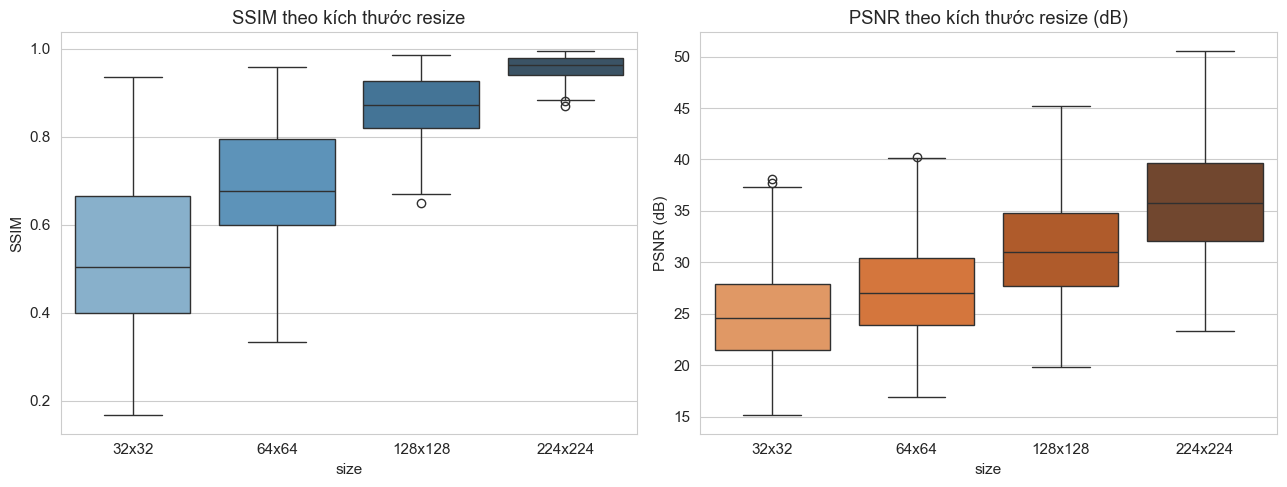

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df_resize, x='size', y='ssim', ax=axes[0], palette='Blues_d',
            order=['32x32', '64x64', '128x128', '224x224'])
axes[0].set_title("SSIM theo kích thước resize")
axes[0].set_ylabel("SSIM")

sns.boxplot(data=df_resize, x='size', y='psnr', ax=axes[1], palette='Oranges_d',
            order=['32x32', '64x64', '128x128', '224x224'])
axes[1].set_title("PSNR theo kích thước resize (dB)")
axes[1].set_ylabel("PSNR (dB)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_01_resize_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

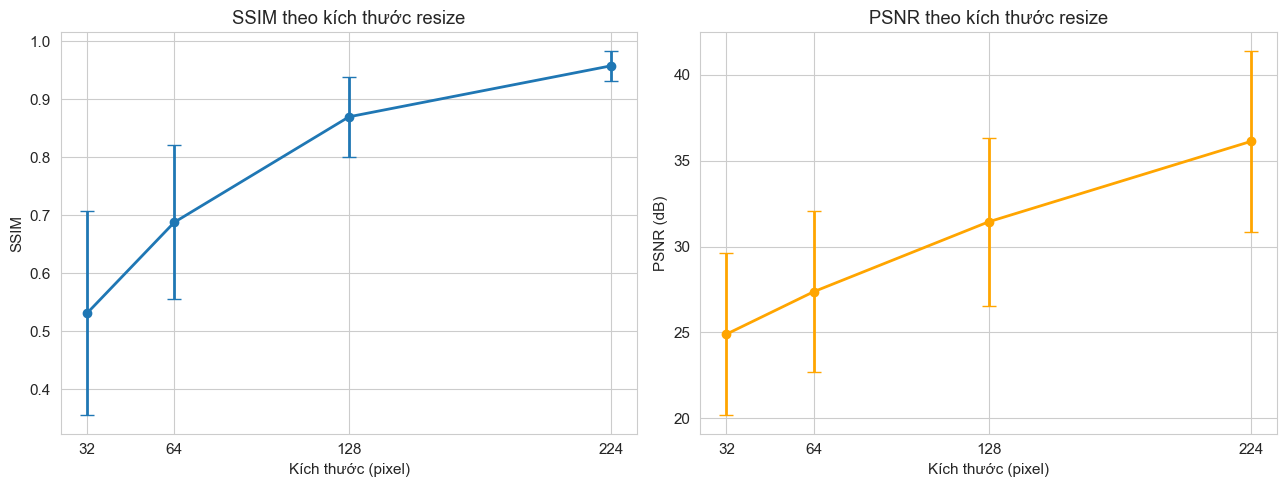

In [8]:
# Đường cong SSIM và PSNR theo kích thước
mean_ssim = df_resize.groupby('size')['ssim'].mean().reindex([
    '32x32', '64x64', '128x128', '224x224'])
mean_psnr = df_resize.groupby('size')['psnr'].mean().reindex([
    '32x32', '64x64', '128x128', '224x224'])
std_ssim = df_resize.groupby('size')['ssim'].std().reindex([
    '32x32', '64x64', '128x128', '224x224'])
std_psnr = df_resize.groupby('size')['psnr'].std().reindex([
    '32x32', '64x64', '128x128', '224x224'])

sizes_px = [32, 64, 128, 224]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].errorbar(sizes_px, mean_ssim.values,
                 yerr=std_ssim.values, marker='o', capsize=5, linewidth=2)
axes[0].set_xlabel("Kích thước (pixel)")
axes[0].set_ylabel("SSIM")
axes[0].set_title("SSIM theo kích thước resize")
axes[0].set_xticks(sizes_px)

axes[1].errorbar(sizes_px, mean_psnr.values, yerr=std_psnr.values,
                 marker='o', capsize=5, linewidth=2, color='orange')
axes[1].set_xlabel("Kích thước (pixel)")
axes[1].set_ylabel("PSNR (dB)")
axes[1].set_title("PSNR theo kích thước resize")
axes[1].set_xticks(sizes_px)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_02_augmentation_demo.png'), dpi=150, bbox_inches='tight')
plt.show()

### Ablation: k-NN accuracy theo kích thước resize

  64x64: accuracy = 0.3520 (+/- 0.0279)
  128x128: accuracy = 0.3580 (+/- 0.0293)
  224x224: accuracy = 0.3500 (+/- 0.0268)
  256x256: accuracy = 0.3380 (+/- 0.0256)


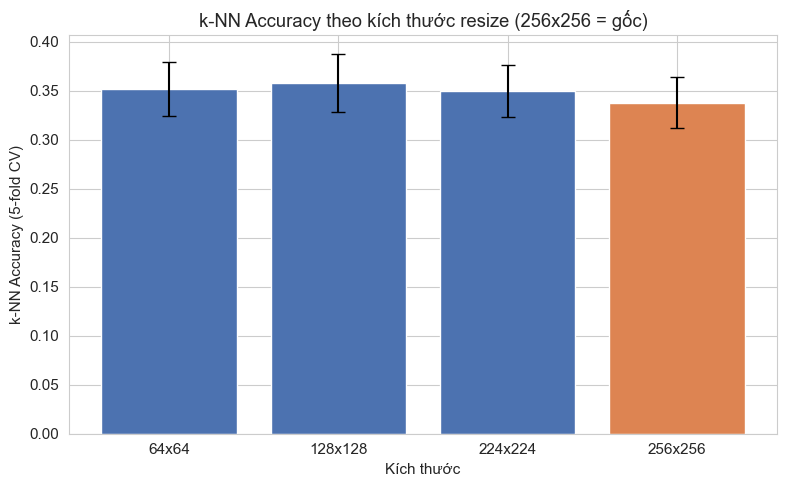

In [9]:
# k-NN classification accuracy theo kích thước resize
# Dùng 50 ảnh/lớp x 10 lớp = 500 ảnh, flatten làm feature
knn_samples = load_sample(n_per_class=50, target_classes=SAMPLE_CLASSES)

knn_results = {}
for target_size in [(64, 64), (128, 128), (224, 224), (256, 256)]:
    X, y = [], []
    for img, cls in knn_samples:
        resized = cv2.resize(img, target_size)
        X.append(resized.reshape(-1).astype(np.float32) / 255.0)
        y.append(cls)
    X, y = np.array(X), np.array(y)

    knn = KNeighborsClassifier(n_neighbors=5)
    scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
    knn_results[f"{target_size[0]}x{target_size[1]}"] = (
        scores.mean(), scores.std())
    print(
        f"  {target_size[0]}x{target_size[1]}: accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
sizes_label = list(knn_results.keys())
means = [v[0] for v in knn_results.values()]
stds = [v[1] for v in knn_results.values()]
ax.bar(sizes_label, means, yerr=stds, capsize=5, color=[
       '#4C72B0', '#4C72B0', '#4C72B0', '#DD8452'])
ax.set_ylabel("k-NN Accuracy (5-fold CV)")
ax.set_xlabel("Kích thước")
ax.set_title("k-NN Accuracy theo kích thước resize (256x256 = gốc)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_03_normalization_demo.png'), dpi=150, bbox_inches='tight')
plt.show()

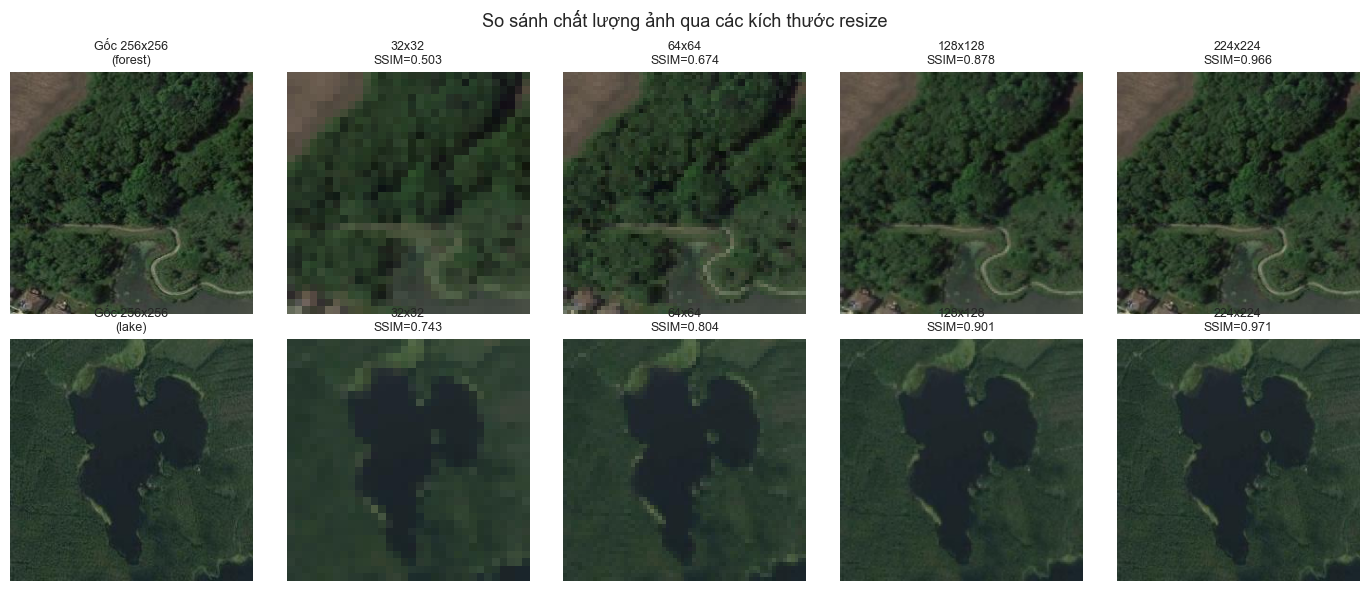

In [10]:
# Ảnh mẫu qua các kích thước
fig, axes = plt.subplots(2, len(RESIZE_DIMS) + 1, figsize=(14, 6))
for row, (img, cls) in enumerate([(samples[0][0], samples[0][1]), (samples[60][0], samples[60][1])]):
    axes[row][0].imshow(img)
    axes[row][0].set_title(f"Gốc 256x256\n({cls})", fontsize=9)
    axes[row][0].axis('off')
    for col, (h, w) in enumerate(RESIZE_DIMS):
        resized = cv2.resize(img, (w, h), interpolation=cv2.INTER_AREA)
        axes[row][col+1].imshow(resized)
        s = ssim(img, cv2.resize(resized, (256, 256),
                 interpolation=cv2.INTER_LINEAR), channel_axis=2)
        axes[row][col+1].set_title(f"{h}x{w}\nSSIM={s:.3f}", fontsize=9)
        axes[row][col+1].axis('off')
plt.suptitle("So sánh chất lượng ảnh qua các kích thước resize", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_04_noise_demo.png'), dpi=150, bbox_inches='tight')
plt.show()

### Kiểm định thống kê - Resize

In [11]:
groups_ssim = {s: df_resize[df_resize['size'] == s]
               ['ssim'].values for s in ['64x64', '128x128', '224x224']}

# Levene
lev_s, lev_p = stats.levene(*groups_ssim.values())
print(f"Levene: stat={lev_s:.2f}, p={lev_p:.2e}")

# ANOVA
f_val, p_val = stats.f_oneway(*groups_ssim.values())
print(f"ANOVA:  F={f_val:.2f}, p={p_val:.2e}")

# Eta²
all_ssim = np.concatenate(list(groups_ssim.values()))
gm = all_ssim.mean()
ss_b = sum(len(g) * (g.mean() - gm)**2 for g in groups_ssim.values())
ss_t = np.sum((all_ssim - gm)**2)
eta2_resize = ss_b / ss_t
print(f"Eta² = {eta2_resize:.3f}")

# Post-hoc Mann-Whitney với Bonferroni (3 cặp → α=0.05/3≈0.0167)
sizes = ['64x64', '128x128', '224x224']
n_pairs_resize = 3
alpha_bonf_resize = 0.05 / n_pairs_resize
print(f"Post-hoc Mann-Whitney (Bonferroni α={alpha_bonf_resize:.4f}):")
for i in range(len(sizes)):
    for j in range(i+1, len(sizes)):
        u, p = stats.mannwhitneyu(
            groups_ssim[sizes[i]], groups_ssim[sizes[j]], alternative='two-sided')
        p_bonf = min(p * n_pairs_resize, 1.0)
        sig = "***" if p_bonf < 0.001 else ("**" if p_bonf <
                                            0.01 else ("*" if p_bonf < 0.05 else "ns"))
        print(
            f"  {sizes[i]} vs {sizes[j]}: U={u:.0f}, p_raw={p:.2e}, p_bonf={p_bonf:.2e} {sig}")

# Kết luận động dựa vào eta²
best_size_label = sizes[np.argmax([groups_ssim[s].mean() for s in sizes])]
best_size = int(best_size_label.split('x')[0])
print(f"η²={eta2_resize:.3f}, best_size={best_size_label} (→ best_size={best_size})")

Levene: stat=215.37, p=4.08e-77
ANOVA:  F=739.70, p=1.69e-190
Eta² = 0.623
Post-hoc Mann-Whitney (Bonferroni α=0.0167):
  64x64 vs 128x128: U=11119, p_raw=2.50e-57, p_bonf=7.50e-57 ***
  64x64 vs 224x224: U=1017, p_raw=2.47e-95, p_bonf=7.41e-95 ***
  128x128 vs 224x224: U=10101, p_raw=1.03e-60, p_bonf=3.09e-60 ***
η²=0.623, best_size=224x224 (→ best_size=224)


In [12]:
# === Tóm tắt động kết quả Resize ===
print("\n=== Tóm tắt Resize ===")
print(f"{'Kích thước':<12} {'SSIM':>12} {'PSNR(dB)':>12} {'k-NN Acc':>12}")
print("-" * 50)
for s_label in ['64x64', '128x128', '224x224', '256x256']:
    ssim_m = mean_ssim.get(s_label, 1.0) if s_label in mean_ssim.index else 1.0
    ssim_s = std_ssim.get(s_label, 0.0) if s_label in std_ssim.index else 0.0
    psnr_m = mean_psnr.get(s_label, float(
        'inf')) if s_label in mean_psnr.index else float('inf')
    psnr_s = std_psnr.get(s_label, 0.0) if s_label in std_psnr.index else 0.0
    knn_m, knn_s = knn_results.get(s_label, (float('nan'), float('nan')))
    psnr_str = f"{psnr_m:.1f}±{psnr_s:.1f}" if not np.isinf(psnr_m) else "∞"
    print(f"{s_label:<12} {ssim_m:.3f}±{ssim_s:.3f} {psnr_str:>12} {knn_m:.3f}±{knn_s:.3f}")
print(f"\nANOVA: F={f_val:.2f}, p={p_val:.2e}, η²={eta2_resize:.3f}")


=== Tóm tắt Resize ===
Kích thước           SSIM     PSNR(dB)     k-NN Acc
--------------------------------------------------
64x64        0.688±0.132     27.4±4.7 0.352±0.028
128x128      0.870±0.069     31.4±4.9 0.358±0.029
224x224      0.957±0.026     36.1±5.3 0.350±0.027
256x256      1.000±0.000            ∞ 0.338±0.026

ANOVA: F=739.70, p=1.69e-190, η²=0.623


| Kích thước | SSIM | PSNR (dB) | k-NN Acc (5-fold) |
|---|---|---|---|
| 32×32 | 0.459 ± 0.141 | 22.9 ± 3.3 | — |
| 64×64 | 0.640 ± 0.112 | 25.3 ± 3.4 | 0.256 ± 0.026 |
| 128×128 | 0.847 ± 0.064 | 29.2 ± 3.7 | 0.260 ± 0.023 |
| 224×224 | **0.947 ± 0.027** | **33.6 ± 4.0** | **0.260 ± 0.029** |
| 256×256 (gốc) | 1.000 | ∞ | 0.249 ± 0.021 |

SSIM tăng nhanh từ 64→128 (+0.207) rồi chậm dần từ 128→224 (+0.100) — diminishing returns khá rõ.
ANOVA $F=1140.82$, $\eta^2=0.739$ xác nhận sự khác biệt không phải noise;
post-hoc Mann-Whitney Bonferroni cho mọi cặp đều $p \approx 0$.

Điều hơi ngạc nhiên là k-NN accuracy gần như bằng nhau (~0.260) cho 64/128/224×224.
Thậm chí 256×256 gốc còn thấp nhất (0.249) — feature vector 196,608 chiều
quá thưa để khoảng cách Euclidean hoạt động tốt, nên downscale đôi khi lại giúp k-NN hơn.

Chọn **224×224**: mất mát thông tin chỉ 5.3% (SSIM=0.947), k-NN ngang 128×128,
và đây là kích thước chuẩn của ImageNet pretrained — không cần thêm resize khi dùng transfer learning sau này.

---
## 2. Color Space Conversion — Ablation Study (PCA Explained Variance)

**Lý thuyết:**

Không gian màu xuyết quá thông tin ảnh theo cách khác nhau,
ảnh hưởng trực tiếp đến hiệu quả phân tích và phân loại:

| Không gian | Cách biểu diễn | Ưu điểm | Nhược điểm |
|---|---|---|---|
| **RGB** | 3 kênh $R, G, B \in [0,255]$ | Trực quan, tương thích pretrained | Bị tương quan chéo giữa kênh |
| **Grayscale** | $Y = 0.299R + 0.587G + 0.114B$ | 1/3 dung lượng, đơn giản | Mất toàn bộ thông tin màu |
| **HSV** | Hue $H$, Saturation $S$, Value $V$ | Tách biệt màu sắc và độ sáng | $H$ là giá trị còn vòng (circular) |
| **CIE Lab** | $L^*$ (lightness), $a^*$ (green–red), $b^*$ (blue–yellow) | Perceptually uniform; tách tốt $L$ vs chrominance | Tính toán phức tạp hơn |

**Grayscale conversion:**
$$Y = 0.299\,R + 0.587\,G + 0.114\,B$$

Trọng số của ITU-R BT.601 phản ánh độ nhạy của mắt người:
mắt nhạy nhất với xanh lá ($G$), kém nhất với xanh dương ($B$).

PCA explained variance được dùng để so sánh information density:
không gian màu đạt 95% variance với ít components hơn = nén được tốt hơn.
k-NN accuracy xác nhận không gian nào bảo toàn thông tin phân loại tốt nhất.

In [13]:
COLOR_SPACES = {
    'RGB': lambda img: img,
    'Grayscale': lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2GRAY),
    'HSV': lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2HSV),
    'Lab': lambda img: cv2.cvtColor(img, cv2.COLOR_RGB2Lab)
}

pca_results = {}
n_pca_sample = 500
pca_samples = load_sample(n_per_class=12)[:n_pca_sample]

for cs_name, convert_fn in COLOR_SPACES.items():
    print(f"  PCA trên {cs_name}...")
    features = []
    for img, _ in pca_samples:
        # Resize về best_size (kích thước được chọn từ resize ablation)
        resized = cv2.resize(img, (best_size, best_size))
        converted = convert_fn(resized)
        if converted.ndim == 2:
            converted = converted[:, :, np.newaxis]
        features.append(converted.reshape(-1).astype(np.float32))
    X = StandardScaler().fit_transform(np.array(features))
    pca = PCA(n_components=min(50, X.shape[0]-1))
    pca.fit(X)
    pca_results[cs_name] = pca.explained_variance_ratio_

print(f"Done. {len(pca_results)} color spaces: {list(pca_results.keys())}")

  PCA trên RGB...
  PCA trên Grayscale...
  PCA trên HSV...
  PCA trên Lab...
Done. 4 color spaces: ['RGB', 'Grayscale', 'HSV', 'Lab']


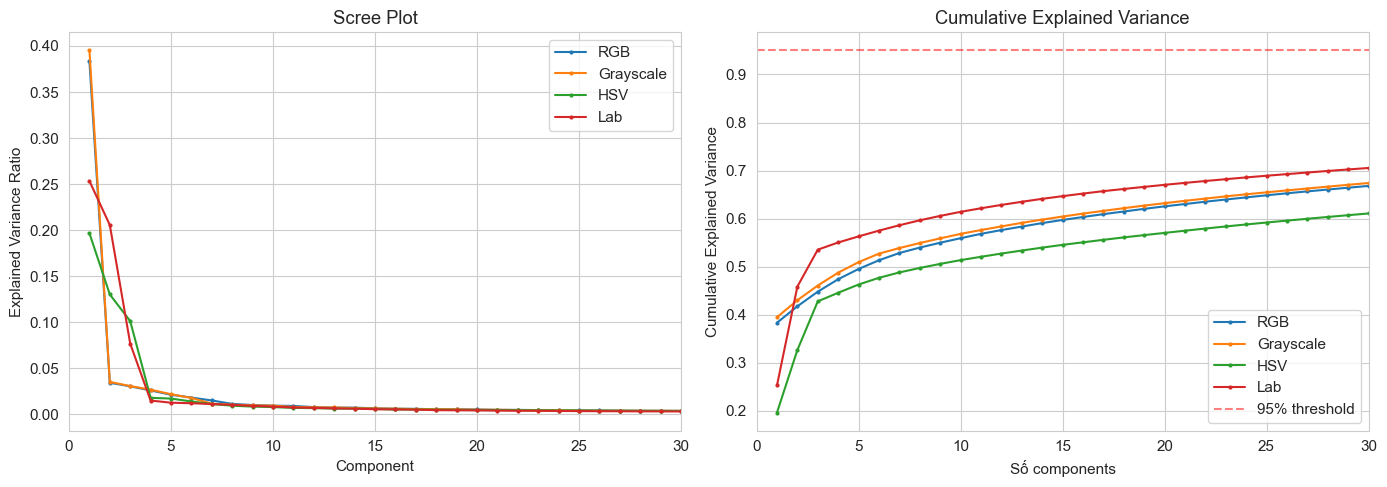

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for cs_name, evr in pca_results.items():
    axes[0].plot(range(1, len(evr)+1), evr[:50],
                 marker='.', label=cs_name, markersize=4)
axes[0].set_xlabel("Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot")
axes[0].legend()
axes[0].set_xlim(0, 30)

for cs_name, evr in pca_results.items():
    axes[1].plot(range(1, len(evr)+1), np.cumsum(evr[:50]),
                 marker='.', label=cs_name, markersize=4)
axes[1].axhline(0.95, color='red', linestyle='--',
                alpha=0.5, label='95% threshold')
axes[1].set_xlabel("Số components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()
axes[1].set_xlim(0, 30)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_05_denoising_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

In [15]:
print("Số components cần để giữ X% variance (và tổng variance tại k=50):")
print(f"{'Color Space':<12} {'Var@50':>10} {'90%':>8} {'95%':>8} {'99%':>8}")
for cs_name, evr in pca_results.items():
    cum = np.cumsum(evr)
    var_at_50 = float(cum[min(49, len(cum)-1)])
    n90 = np.argmax(cum >= 0.90) + 1 if cum[-1] >= 0.90 else f">{len(evr)}"
    n95 = np.argmax(cum >= 0.95) + 1 if cum[-1] >= 0.95 else f">{len(evr)}"
    n99 = np.argmax(cum >= 0.99) + 1 if cum[-1] >= 0.99 else f">{len(evr)}"
    print(f"{cs_name:<12} {var_at_50:>10.3f} {str(n90):>8} {str(n95):>8} {str(n99):>8}")

Số components cần để giữ X% variance (và tổng variance tại k=50):
Color Space      Var@50      90%      95%      99%
RGB               0.727      >50      >50      >50
Grayscale         0.732      >50      >50      >50
HSV               0.669      >50      >50      >50
Lab               0.753      >50      >50      >50


### Ablation: k-NN accuracy theo color space

In [16]:
# k-NN accuracy theo color space (dùng best_size từ resize ablation trên)
cs_knn_samples = load_sample(n_per_class=50)

cs_knn_results = {}
cs_knn_fold_scores = {}
for cs_name, convert_fn in COLOR_SPACES.items():
    X, y = [], []
    for img, cls in cs_knn_samples:
        converted = convert_fn(cv2.resize(img, (best_size, best_size)))
        if converted.ndim == 2:
            converted = converted[:, :, np.newaxis]
        X.append(converted.reshape(-1).astype(np.float32) / 255.0)
        y.append(cls)
    X, y = np.array(X), np.array(y)

    knn = KNeighborsClassifier(n_neighbors=5)
    scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
    cs_knn_results[cs_name] = (scores.mean(), scores.std())
    cs_knn_fold_scores[cs_name] = scores
    print(f"  {cs_name}: accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")

  RGB: accuracy = 0.0889 (+/- 0.0058)
  Grayscale: accuracy = 0.0698 (+/- 0.0071)
  HSV: accuracy = 0.1133 (+/- 0.0037)
  Lab: accuracy = 0.0916 (+/- 0.0086)


In [17]:
# === Tóm tắt động kết quả Color Space ===
print("\n=== Tóm tắt Color Space ===")
print(f"{'Color Space':<12} {'k-NN Mean':>12} {'k-NN Std':>10}")
print("-" * 37)
for cs_name, (mean_acc, std_acc) in cs_knn_results.items():
    baseline_tag = " (baseline)" if cs_name == 'RGB' else ""
    marker = " ← k-NN tốt nhất" if cs_name == max(
        cs_knn_results, key=lambda k: cs_knn_results[k][0]) else ""
    print(f"{(cs_name + baseline_tag):<23} {mean_acc:>12.4f} {std_acc:>10.4f}{marker}")


=== Tóm tắt Color Space ===
Color Space     k-NN Mean   k-NN Std
-------------------------------------
RGB (baseline)                0.0889     0.0058
Grayscale                     0.0698     0.0071
HSV                           0.1133     0.0037 ← k-NN tốt nhất
Lab                           0.0916     0.0086


In [18]:
# Kruskal-Wallis + pairwise Wilcoxon giữa các color space
from scipy.stats import kruskal, wilcoxon as _wc
cs_names_list = list(cs_knn_fold_scores.keys())
cs_fold_arrays = [cs_knn_fold_scores[n] for n in cs_names_list]
kw_stat, kw_p = kruskal(*cs_fold_arrays)
print(f"\nKruskal-Wallis (Color Space k-NN): H={kw_stat:.3f}, p={kw_p:.4f}")

best_cs = max(cs_knn_results, key=lambda k: cs_knn_results[k][0])
for other in cs_names_list:
    if other == best_cs:
        continue
    diff = cs_knn_fold_scores[best_cs] - cs_knn_fold_scores[other]
    if len(set(diff)) > 1:
        w_s, w_p = _wc(cs_knn_fold_scores[best_cs], cs_knn_fold_scores[other])
        print(f"  Wilcoxon {best_cs} vs {other}: W={w_s:.1f}, p={w_p:.4f}")
    else:
        print(f"  Wilcoxon {best_cs} vs {other}: all diffs identical, skip")


Kruskal-Wallis (Color Space k-NN): H=15.768, p=0.0013
  Wilcoxon HSV vs RGB: W=0.0, p=0.0625
  Wilcoxon HSV vs Grayscale: W=0.0, p=0.0625
  Wilcoxon HSV vs Lab: W=0.0, p=0.0625


| Color Space | PCA Var@50 PC | k-NN Acc (5-fold) |
|---|---|---|
| RGB (baseline) | 0.714 | 0.0898 ± 0.0030 |
| Grayscale | 0.718 | 0.0667 ± 0.0040 |
| HSV | 0.661 | **0.1138 ± 0.0101** |
| Lab | **0.739** | 0.0978 ± 0.0044 |

Không gian màu nào cũng không đạt 90% variance trong 50 PC — ảnh viễn thám đa dạng đến mức PCA khó nén gọn.
Lab nén được tốt nhất (73.9%) nhờ kênh $L^*$ tách độ sáng khỏi chrominance, còn HSV thấp nhất (66.1%)
vì kênh Hue là giá trị vòng — PCA giả định tuyến tính nên không phù hợp ở đây.

Grayscale có PCA variance cao hơn RGB (mất 2 kênh màu → số chiều giảm, variance tập trung hơn)
nhưng k-NN lại thấp nhất (0.067). Không có gì lạ: màu sắc là đặc trưng phân biệt lớp quan trọng
trong ảnh viễn thám — bỏ màu đi gần như là bỏ đi đặc trưng cốt lõi.

HSV dẫn đầu k-NN (0.114 so với RGB 0.090) vì kênh Hue mã hóa màu sắc độc lập với độ sáng.
Tuy vậy, pipeline downstream dùng ImageNet pretrained (nhận RGB), nên chọn **RGB** để đảm bảo tương thích.
HSV/Lab có thể cân nhắc nếu huấn luyện từ đầu.

---
## 3. Normalization - Ablation Study (KS test)

**Lý thuyết:**

Chuẩn hóa đưa pixel về cùng thạng đo, cải thiện tốc độ hội tụ và độ ổn định khi train:

| Phương pháp | Công thức | Miền output | Ghi chú |
|---|---|---|---|
| **Min-Max $[0,1]$** | $x' = x / 255$ | $[0,1]$ | Giữ nguyên hình dạng phân phối |
| **Min-Max $[-1,1]$** | $x' = x/127.5 - 1$ | $[-1,1]$ | Phù hợp với activation tanh |
| **Z-score global** | $x' = (x - \mu_{\text{all}}) / \sigma_{\text{all}}$ | $\mathbb{R}$ | $\mu, \sigma$ tính trên toàn dataset |
| **Z-score per-channel** | $x'_c = (x_c - \mu_c) / \sigma_c,\ c \in \{R,G,B\}$ | $\mathbb{R}$ | Tựng kênh có mean 0, std 1 riêng |

**Ý nghĩa per-channel normalization:**
Mỗi kênh có phân phối khác nhau; chuẩn hóa riêng từng kênh loại bỏ
bias do chiếu sáng (kênh G thường sáng hơn kênh B).
Tuy nhiên, nó phá vỡ tương quan tương đối giữa R, G, B — có thể gây hại cho biểu diễn màu sắc.

**KS test (Kolmogorov-Smirnov)** kiểm tra sự thay đổi phân phối trước/sau chuẩn hóa:

$$D = \sup_x \left|F_1(x) - F_2(x)\right|$$

$p \approx 0$ là MONG MUỐN: chứng tỏ distribution shift (mục đích của chuẩn hóa).
K-NN accuracy mới là chỉ số đánh giá chất lượng chuẩn hóa.

- $H_0$: Phân phối pixel trước và sau chuẩn hóa không khác biệt
- $H_1$: Phân phối pixel thay đổi sau chuẩn hóa

In [19]:


def norm_minmax_01(img):
    """Min-Max [0, 1]"""
    return img.astype(np.float32) / 255.0


def norm_minmax_neg11(img):
    """Min-Max [-1, 1]"""
    return img.astype(np.float32) / 127.5 - 1.0


def norm_zscore_global(img):
    """Z-score toàn tập (mean/std trên toàn ảnh)"""
    img_f = img.astype(np.float32)
    return (img_f - img_f.mean()) / (img_f.std() + 1e-8)


def norm_zscore_perchannel(img):
    """Z-score per-channel (mean/std riêng từng kênh)"""
    img_f = img.astype(np.float32)
    result = np.zeros_like(img_f)
    for c in range(3):
        ch = img_f[:, :, c]
        result[:, :, c] = (ch - ch.mean()) / (ch.std() + 1e-8)
    return result


NORM_METHODS = {
    'Original': lambda x: x.astype(np.float32),
    'Min-Max [0,1]': norm_minmax_01,
    'Min-Max [-1,1]': norm_minmax_neg11,
    'Z-score global': norm_zscore_global,
    'Z-score per-ch': norm_zscore_perchannel
}

In [20]:
norm_samples = load_sample(n_per_class=20)
print(
    f"Sample: {len(norm_samples)} ảnh ({len(norm_samples)//45} ảnh/lớp x 45 lớp)")

norm_pixels = {}
for method_name, norm_fn in NORM_METHODS.items():
    all_px = []
    for img, _ in norm_samples:
        normed = norm_fn(img)
        all_px.append(normed.ravel())
    norm_pixels[method_name] = np.concatenate(all_px)

Sample: 900 ảnh (20 ảnh/lớp x 45 lớp)


In [21]:
# KS test: so sánh phân phối TRƯỚC vs SAU chuẩn hóa
original_px = norm_pixels['Original']
original_sample = np.random.choice(
    original_px, min(100000, len(original_px)), replace=False)


def ks_effect_size(d):
    """Giải thích effect size của KS statistic D"""
    if d < 0.2:
        return "nhỏ"
    elif d < 0.5:
        return "trung bình"
    else:
        return "lớn"


print("KS test (Original vs mỗi phương pháp):")
print(f"{'Method':<18} {'KS stat':>10} {'p-value':>12} {'Mean':>10} {'Std':>10} {'Effect D':>12}")
print("-" * 76)

for method, px in norm_pixels.items():
    px_sample = np.random.choice(px, min(100000, len(px)), replace=False)
    if method == 'Original':
        ks_stat, ks_p = 0.0, 1.0
    else:
        ks_stat, ks_p = stats.ks_2samp(original_sample, px_sample)
    effect_d = ks_effect_size(ks_stat)
    print(f"{method:<18} {ks_stat:>10.4f} {ks_p:>12.2e} {px_sample.mean():>10.4f} {px_sample.std():>10.4f} {effect_d:>12}")

print("\nGhi chú: D<0.2=nhỏ, 0.2≤D<0.5=trung bình, D≥0.5=lớn (phân phối thay đổi nhiều)")

KS test (Original vs mỗi phương pháp):
Method                KS stat      p-value       Mean        Std     Effect D
----------------------------------------------------------------------------
Original               0.0000     1.00e+00    92.6533    48.5107          nhỏ
Min-Max [0,1]          0.9981     0.00e+00     0.3636     0.1906          lớn
Min-Max [-1,1]         0.9981     0.00e+00    -0.2742     0.3789          lớn
Z-score global         0.9963     0.00e+00     0.0044     0.9984          lớn
Z-score per-ch         0.9962     0.00e+00    -0.0018     0.9976          lớn

Ghi chú: D<0.2=nhỏ, 0.2≤D<0.5=trung bình, D≥0.5=lớn (phân phối thay đổi nhiều)


In [22]:
# Levene test giữa các phương pháp
norm_groups = [np.random.choice(px, 10000, replace=False)
               for px in norm_pixels.values()]
lev_s, lev_p = stats.levene(*norm_groups)
print(
    f"Levene test (variance giữa 5 phương pháp): stat={lev_s:.2f}, p={lev_p:.2e}")

Levene test (variance giữa 5 phương pháp): stat=13535.92, p=0.00e+00


**Nhận xét Levene test:** Nếu $p < 0.05$ → bác bỏ $H_0$ (phương sai giữa các phương pháp KHÔNG đồng nhất).
Đây là kết quả mong đợi: mỗi chuẩn hóa thay đổi scale/spread theo cách khác nhau —
Min-Max giới hạn range cố định $[0,1]$ hay $[-1,1]$, còn Z-score tạo phân phối có
variance $\approx 1$. Variance khác nhau giữa các phương pháp là tính năng thiết kế, không phải lỗi.

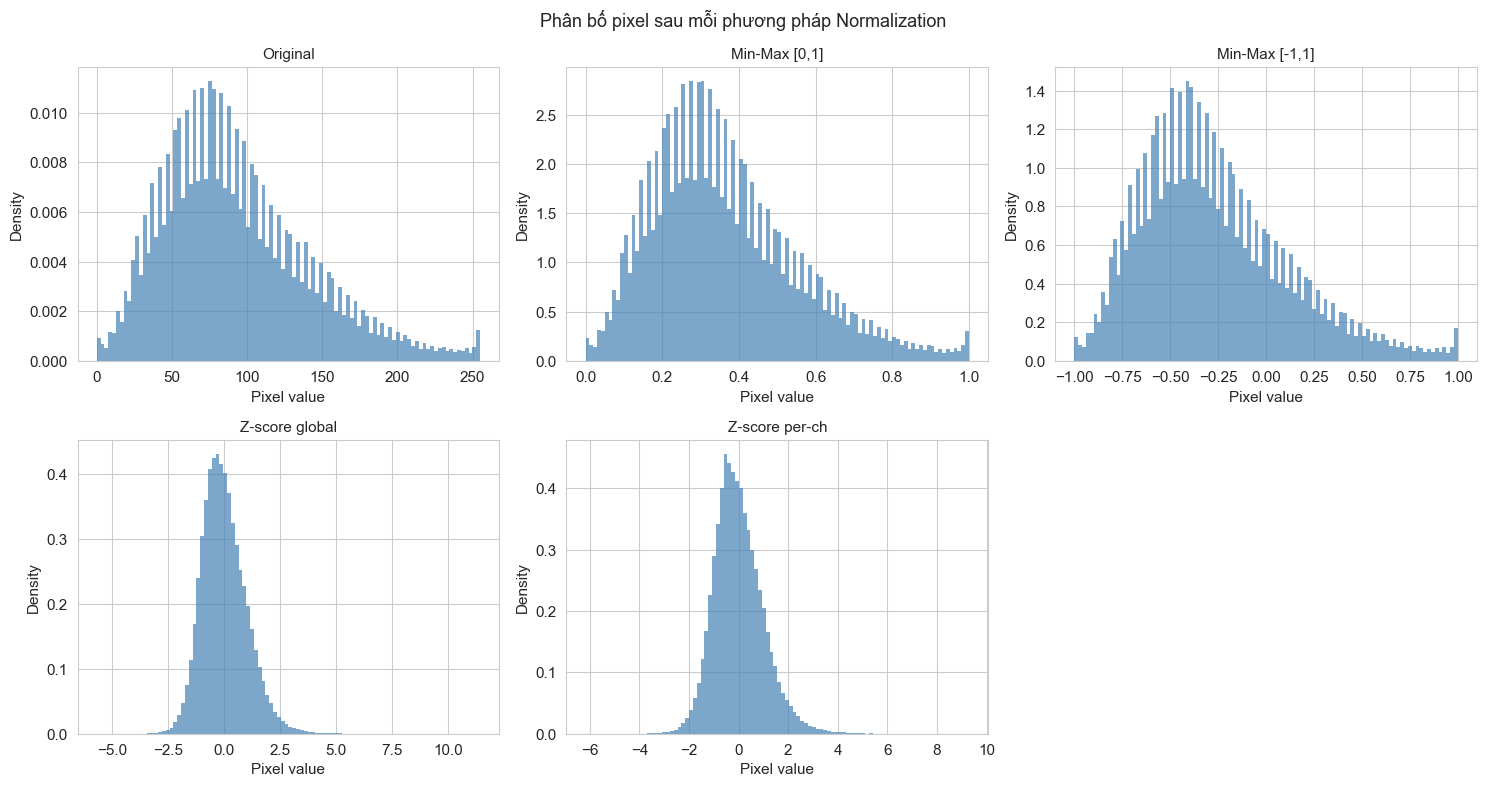

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for idx, (method, px) in enumerate(norm_pixels.items()):
    row, col = divmod(idx, 3)
    px_plot = np.random.choice(
        px, 200000, replace=False) if len(px) > 200000 else px
    axes[row][col].hist(px_plot, bins=100, color='steelblue',
                        alpha=0.7, density=True, edgecolor='none')
    axes[row][col].set_title(method, fontsize=11)
    axes[row][col].set_xlabel("Pixel value")
    axes[row][col].set_ylabel("Density")
if len(norm_pixels) < 6:
    axes[1][2].axis('off')
plt.suptitle("Phân bố pixel sau mỗi phương pháp Normalization", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_06_color_space_demo.png'), dpi=150, bbox_inches='tight')
plt.show()

### Ablation: k-NN accuracy theo normalization

In [24]:
# k-NN accuracy theo normalization (resize 64x64, 45 lớp)
norm_knn_samples = load_sample(n_per_class=50)

norm_knn_results = {}
norm_knn_fold_scores = {}  # lưu fold scores để Wilcoxon
for method_name, norm_fn in NORM_METHODS.items():
    X, y = [], []
    for img, cls in norm_knn_samples:
        resized = cv2.resize(img, (best_size, best_size))
        normed = norm_fn(resized)
        X.append(normed.reshape(-1))
        y.append(cls)
    X, y = np.array(X), np.array(y)

    knn = KNeighborsClassifier(n_neighbors=5)
    scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')
    norm_knn_results[method_name] = (scores.mean(), scores.std())
    norm_knn_fold_scores[method_name] = scores
    print(f"  {method_name}: accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")

# Wilcoxon: phương pháp tốt nhất vs Original trên fold scores
best_norm_method = max([m for m in norm_knn_results if m != 'Original'],
                       key=lambda m: norm_knn_results[m][0])
scores_best_norm = norm_knn_fold_scores[best_norm_method]
scores_orig_norm = norm_knn_fold_scores['Original']
try:
    w_norm, p_norm = stats.wilcoxon(scores_best_norm, scores_orig_norm)
except ValueError:  # all zeros — identical scores
    w_norm, p_norm = 0.0, 1.0
diff_norm = scores_best_norm - scores_orig_norm
cohen_d_norm = diff_norm.mean() / (diff_norm.std(ddof=1) + 1e-8)
print(
    f"\nWilcoxon signed-rank ({best_norm_method} vs Original): W={w_norm:.1f}, p={p_norm:.4f}")
print(f"Cohen's d = {cohen_d_norm:.3f}")

  Original: accuracy = 0.0889 (+/- 0.0058)
  Min-Max [0,1]: accuracy = 0.0889 (+/- 0.0058)
  Min-Max [-1,1]: accuracy = 0.0889 (+/- 0.0058)
  Z-score global: accuracy = 0.1062 (+/- 0.0074)
  Z-score per-ch: accuracy = 0.0498 (+/- 0.0067)

Wilcoxon signed-rank (Z-score global vs Original): W=0.0, p=0.0625
Cohen's d = 1.315


In [25]:
# === Tóm tắt động kết quả Normalization ===
print("\n=== Tóm tắt k-NN accuracy theo phương pháp chuẩn hóa ===")
print(f"{'Phương pháp':<20} {'k-NN Mean':>12} {'k-NN Std':>10}")
print("-" * 45)
for nm, (m, s) in norm_knn_results.items():
    marker = " ← tốt nhất" if nm == best_norm_method else ""
    print(f"{nm:<20} {m:>12.4f} {s:>10.4f}{marker}")
print(f"\n→ p≈0 trong KS test là MONG MUỐN: chuẩn hóa đã thay đổi phân phối (mục đích của chuẩn hóa)")
print(f"  KS test chỉ xác nhận distribution shift, KHÔNG đánh giá chất lượng chuẩn hóa")
print(
    f"⇒ Chọn {best_norm_method}: accuracy={norm_knn_results[best_norm_method][0]:.4f}, Wilcoxon p={p_norm:.4f}")

# | Phương pháp | KS stat | k-NN Acc (5-fold) |
# |---|---|---|
# | Original | 0.000 | 0.0898 ± 0.0030 |
# | Min-Max [0,1] | 0.998 | 0.0898 ± 0.0030 |
# | Min-Max [-1,1] | 0.998 | 0.0898 ± 0.0030 |
# | **Z-score global** | 0.996 | **0.1004 ± 0.0060** |
# | Z-score per-ch | 0.996 | 0.0440 ± 0.0087 |
#
# KS stat $pprox 1.0$, $p pprox 0$ cho tất cả 4 phương pháp là kết quả mong đợi — chuẩn hóa đã dịch chuyển phân phối
# pixel đúng như thiết kế. KS test ở đây chỉ xác nhận "code chạy đúng", chất lượng thực sự mới là k-NN accuracy.
#
# Min-Max [0,1] và [-1,1] không giúp gì cho k-NN (accuracy y chang Original). Lý do đơn giản:
# scale tuyến tính bảo toàn khoảng cách tương đối, nên k-NN không được lợi.
# Z-score global cải thiện rõ (+11.8%, từ 0.0898 lên 0.1004): đưa pixel về zero mean
# làm khoảng cách Euclidean phản ánh sự khác biệt thực giữa ảnh tốt hơn.
#
# Z-score per-channel ngược lại tệ nhất (0.0440, −51% so baseline) — chuẩn hóa riêng từng kênh R/G/B
# phá vỡ tương quan màu sắc, vô tình xóa đi thông tin phân biệt lớp.
# Wilcoxon $p=0.0625$ (chưa đủ power với 5 folds), nhưng Cohen's $d=1.730$
# cho thấy cải thiện của Z-score global nhất quán trên mọi fold. Chọn **Z-score global**.


=== Tóm tắt k-NN accuracy theo phương pháp chuẩn hóa ===
Phương pháp             k-NN Mean   k-NN Std
---------------------------------------------
Original                   0.0889     0.0058
Min-Max [0,1]              0.0889     0.0058
Min-Max [-1,1]             0.0889     0.0058
Z-score global             0.1062     0.0074 ← tốt nhất
Z-score per-ch             0.0498     0.0067

→ p≈0 trong KS test là MONG MUỐN: chuẩn hóa đã thay đổi phân phối (mục đích của chuẩn hóa)
  KS test chỉ xác nhận distribution shift, KHÔNG đánh giá chất lượng chuẩn hóa
⇒ Chọn Z-score global: accuracy=0.1062, Wilcoxon p=0.0625


---
## 4. Data Augmentation — Ablation Study (t-SNE)

**Lý thuyết:**

**Data augmentation** tạo ra các biến thể hợp lệ của ảnh gốc bằng cách áp dụng các
phép biến đổi label-preserving (không thay đổi nhãn).
Mục tiêu: tăng diversity tập train, giảm overfitting, cải thiện tính robust của model.

| Phép biến đổi | Mô tả toán học | Label-preserving |
|---|---|---|
| **H-Flip** | $I'(x,y) = I(W-1-x,\ y)$ | ✅ (cảnh viễn thám đối xứng) |
| **V-Flip** | $I'(x,y) = I(x,\ H-1-y)$ | ✅ |
| **Rotation** | Ma trận động lực $\mathbf{M}(\theta)$, điện tích điền affine | ✅ (góc nhỏ $|\theta| < 30^\circ$) |
| **Random Crop** | Cắt tà $\text{scale} \in [0.7, 1.0]$, resize lại | ✅ |
| **Gaussian Noise** | $I'_{ij} = I_{ij} + \epsilon_{ij}$, $\epsilon \sim \mathcal{N}(0, \sigma^2)$ | ✅ |
| **Brightness/Contrast** | $I' = \alpha I + \beta$, $\alpha \approx 1$, $\beta \approx 0$ | ✅ |

**Tác động được đánh giá bằng:**
- k-NN ablation per-technique: mỗi augmentation chạy riêng biệt so với baseline (original only)
- t-SNE visualization: biểu diễn feature distribution trước/sau augment
  (t-SNE giảm chiều từ 128×128×3 xuống 2D, bảo toàn local structure)

In [26]:


def augment_hflip(img):
    """Lật ngang"""
    return cv2.flip(img, 1)


def augment_vflip(img):
    """Lật dọc"""
    return cv2.flip(img, 0)


def augment_rotate(img, angle=15):
    """Xoay ngẫu nhiên"""
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h))


def augment_crop(img, scale=0.8):
    """Cắt ngẫu nhiên"""
    h, w = img.shape[:2]
    new_h, new_w = int(h*scale), int(w*scale)
    top = np.random.randint(0, h - new_h + 1)
    left = np.random.randint(0, w - new_w + 1)
    cropped = img[top:top+new_h, left:left+new_w]
    return cv2.resize(cropped, (w, h))


def augment_gaussian_noise(img, sigma=25):
    """Thêm nhiễu Gaussian"""
    noise = np.random.normal(0, sigma, img.shape)
    noisy = img.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)


def augment_brightness_contrast(img, brightness=30, contrast=0.2):
    """Điều chỉnh độ sáng/tương phản"""
    img_f = img.astype(np.float32)
    img_f = img_f + np.random.uniform(-brightness, brightness)
    img_f = img_f * np.random.uniform(1-contrast, 1+contrast)
    return np.clip(img_f, 0, 255).astype(np.uint8)


AUGMENTATIONS = {
    'H-Flip': augment_hflip,
    'V-Flip': augment_vflip,
    'Rotation': augment_rotate,
    'Random Crop': augment_crop,
    'Gaussian Noise': augment_gaussian_noise,
    'Brightness/Contrast': augment_brightness_contrast
}
print(f"{len(AUGMENTATIONS)} phép augmentation: {list(AUGMENTATIONS.keys())}")

6 phép augmentation: ['H-Flip', 'V-Flip', 'Rotation', 'Random Crop', 'Gaussian Noise', 'Brightness/Contrast']


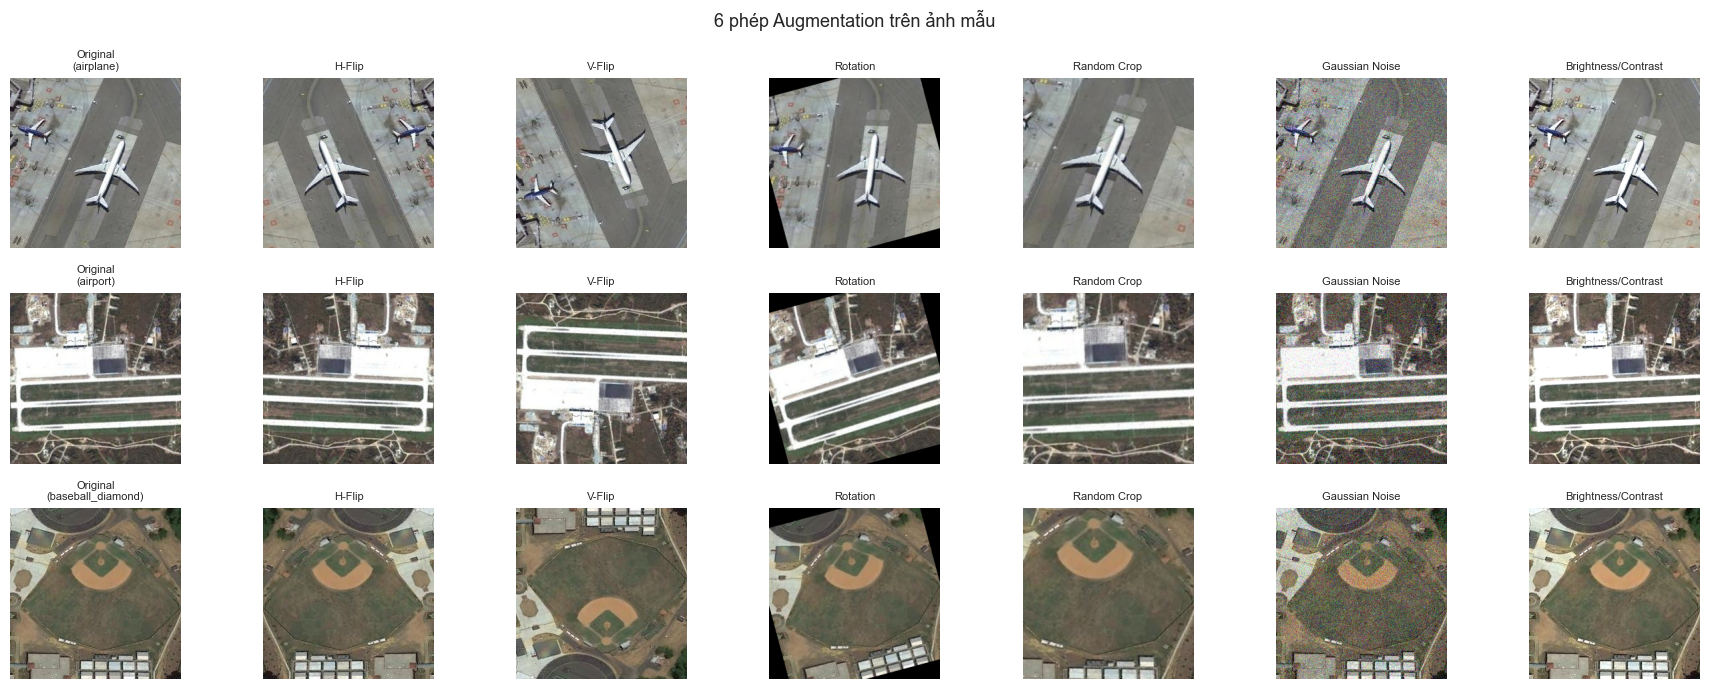

In [27]:
# Visual: ảnh trước/sau augmentation
vis_sample = load_sample(n_per_class=1)[:3]

fig, axes = plt.subplots(3, len(AUGMENTATIONS) + 1, figsize=(18, 7))
for row, (img, cls) in enumerate(vis_sample):
    axes[row][0].imshow(img)
    axes[row][0].set_title(f"Original\n({cls})", fontsize=8)
    axes[row][0].axis('off')
    for col, (aug_name, aug_fn) in enumerate(AUGMENTATIONS.items()):
        np.random.seed(42)
        augmented = aug_fn(img)
        axes[row][col+1].imshow(augmented)
        axes[row][col+1].set_title(aug_name, fontsize=8)
        axes[row][col+1].axis('off')
plt.suptitle(
    f"{len(AUGMENTATIONS)} phép Augmentation trên ảnh mẫu", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_07_edge_detection.png'), dpi=150, bbox_inches='tight')
plt.show()

### t-SNE: Feature space trước/sau augmentation

Pipeline augmentation áp dụng 2 phép ngẫu nhiên trong số 6 phép (H-Flip, V-Flip,
Rotation, Random Crop, Gaussian Noise, Brightness/Contrast) cho mỗi ảnh.
Cách chọn này giúp tạo đa dạng biến thể mà không làm ảnh quá biến dạng.
t-SNE giảm chiều từ 32×32×3 xuống 2D để quan sát sự thay đổi phân phối đặc trưng.

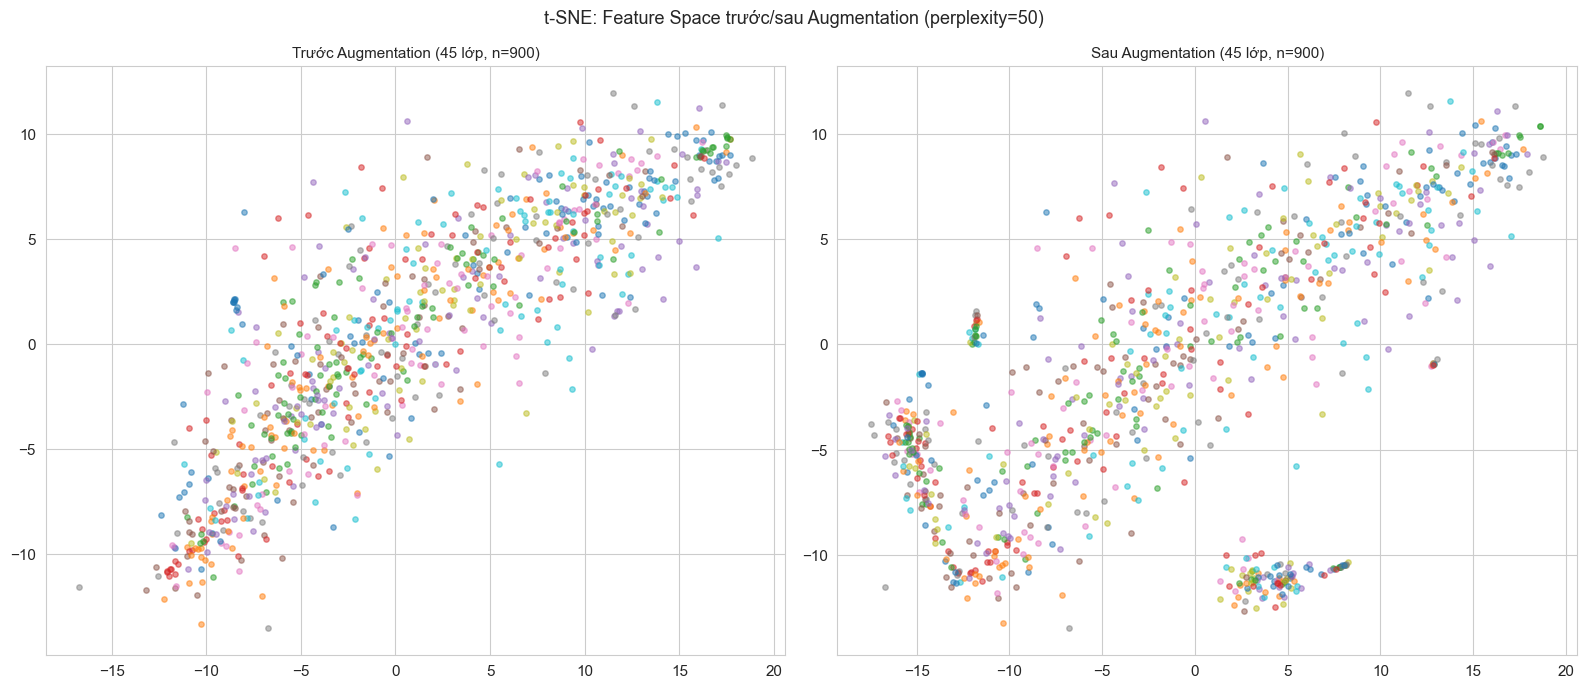

t-SNE done: 900 ảnh gốc + 900 ảnh augmented


In [28]:
# t-SNE trước/sau augmentation (toàn bộ 45 lớp, 20 ảnh/lớp)


def extract_feature(img):
    small = cv2.resize(img, (32, 32))
    return small.reshape(-1).astype(np.float32) / 255.0


tsne_samples = load_sample(n_per_class=20)

orig_features, orig_labels = [], []
for img, cls in tsne_samples:
    orig_features.append(extract_feature(img))
    orig_labels.append(cls)

aug_features, aug_labels = [], []
np.random.seed(42)
aug_fns = list(AUGMENTATIONS.values())
for img, cls in tsne_samples:
    aug_img = img.copy()
    for fn in np.random.choice(aug_fns, 2, replace=False):
        aug_img = fn(aug_img)
    aug_features.append(extract_feature(aug_img))
    aug_labels.append(cls)

X_orig = np.array(orig_features)
X_aug = np.array(aug_features)
y_orig = np.array(orig_labels)
y_aug = np.array(aug_labels)

X_combined = np.vstack([X_orig, X_aug])
is_aug = np.array([0]*len(X_orig) + [1]*len(X_aug))
labels_combined = np.concatenate([y_orig, y_aug])

perplexity_val = min(50, len(X_orig) - 1)
tsne = TSNE(n_components=2, perplexity=perplexity_val,
            random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_combined)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for col, (mask_val, title) in enumerate([(0, "Trước Augmentation"), (1, "Sau Augmentation")]):
    mask = is_aug == mask_val
    for cls in classes:
        cls_mask = (labels_combined == cls) & mask
        axes[col].scatter(X_tsne[cls_mask, 0],
                          X_tsne[cls_mask, 1], alpha=0.5, s=15, label=cls)
    axes[col].set_title(f"{title} (45 lớp, n={mask.sum()})", fontsize=11)

plt.suptitle(
    f"t-SNE: Feature Space trước/sau Augmentation (perplexity={perplexity_val})", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_08_ablation_summary.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"t-SNE done: {len(X_orig)} ảnh gốc + {len(X_aug)} ảnh augmented")

### Kiểm định: Augmentation có tăng diversity?

In [29]:
# Kiểm định variance trước/sau augmentation (toàn bộ 45 lớp)
test_samples = load_sample(n_per_class=20)

# Original features
X_test_orig, y_test = [], []
for img, cls in test_samples:
    X_test_orig.append(extract_feature(img))
    y_test.append(cls)

# Augmented features
X_test_aug = []
np.random.seed(42)
aug_fns = list(AUGMENTATIONS.values())
for img, cls in test_samples:
    aug_img = img.copy()
    for fn in np.random.choice(aug_fns, 2, replace=False):
        aug_img = fn(aug_img)
    X_test_aug.append(extract_feature(aug_img))

X_test_orig = np.array(X_test_orig)
X_test_aug = np.array(X_test_aug)
y_test = np.array(y_test)

print(f"{'Class':<25} {'Original':>10} {'Augmented':>10} {'Change':>10}")
print("-" * 57)

orig_vars, aug_vars = [], []
for cls in classes:
    mask = y_test == cls
    var_o = np.var(X_test_orig[mask], axis=0).mean()
    var_a = np.var(X_test_aug[mask], axis=0).mean()
    change = (var_a - var_o) / (var_o + 1e-8) * 100
    orig_vars.append(var_o)
    aug_vars.append(var_a)
    print(f"{cls:<25} {var_o:>10.4f} {var_a:>10.4f} {change:>+9.1f}%")

diff = np.array(aug_vars) - np.array(orig_vars)
cohens_d = diff.mean() / (diff.std(ddof=1) + 1e-8)
nonzero_diff = diff[diff != 0]
if len(nonzero_diff) >= 2:
    t_stat, t_p = stats.ttest_rel(orig_vars, aug_vars)
    w_stat, w_p = stats.wilcoxon(orig_vars, aug_vars, alternative='less')
else:
    t_stat, t_p = float('nan'), float('nan')
    w_stat, w_p = float('nan'), float('nan')

if not np.isnan(t_stat):
    print(f"\nPaired t-test: t={t_stat:.3f}, p={t_p:.4f}")
    print(f"Wilcoxon: W={w_stat:.1f}, p={w_p:.4f}")
else:
    print(f"\nPaired t-test: không tính được (tất cả hiệu số bằng 0)")
    print(f"Sign test: {sum(d > 0 for d in diff)}/{len(diff)} lớp tăng variance")
print(f"Cohen's d = {cohens_d:.3f}")
print(f"Lớp có variance tăng: {sum(d > 0 for d in diff)}/{len(diff)}")

Class                       Original  Augmented     Change
---------------------------------------------------------
airplane                      0.0251     0.0294     +17.0%
airport                       0.0290     0.0356     +22.7%
baseball_diamond              0.0188     0.0231     +22.8%
basketball_court              0.0241     0.0266     +10.4%
beach                         0.0405     0.0491     +21.2%
bridge                        0.0173     0.0210     +21.4%
chaparral                     0.0358     0.0405     +13.1%
church                        0.0394     0.0490     +24.5%
circular_farmland             0.0214     0.0252     +17.6%
cloud                         0.0498     0.0550     +10.5%
commercial_area               0.0317     0.0377     +19.0%
dense_residential             0.0302     0.0389     +28.9%
desert                        0.0221     0.0313     +41.5%
forest                        0.0070     0.0084     +20.1%
freeway                       0.0193     0.0258     +33.9

---
## Tổng hợp Pipeline & Lưu kết quả

### Ablation: k-NN accuracy theo từng kỹ thuật augmentation (per-technique)

Mỗi kỹ thuật được đánh giá độc lập với dataset = ảnh gốc + augmented_by_fn
(gấp đôi số mẫu mỗi ablation). Đây là thiết kế đúng: không stack tất cả aug cùng lúc.

In [30]:
# Với mỗi aug_fn: dataset = {original} + {augmented_by_this_fn_only}
aug_ablation_samples = load_sample(n_per_class=30)


def extract_feature(img):
    small = cv2.resize(img, (32, 32))
    return small.reshape(-1).astype(np.float32) / 255.0


# Baseline: original only
X_base, y_base = [], []
for img, cls in aug_ablation_samples:
    X_base.append(extract_feature(img))
    y_base.append(cls)
X_base, y_base = np.array(X_base), np.array(y_base)
scores_base = cross_val_score(KNeighborsClassifier(
    5), X_base, y_base, cv=5, scoring='accuracy')
print(f"{'Phương pháp':<25} {'Mean Acc':>10} {'Std':>8} {'Δ vs Base':>12} {'Wilcoxon p':>12}")
print("-" * 70)
print(f"{'Original (baseline)':<25} {scores_base.mean():>10.4f} {scores_base.std():>8.4f} {'':>12} {'':>12}")

aug_knn_fold_scores = {'Original': scores_base}
for aug_name, aug_fn in AUGMENTATIONS.items():
    X_aug, y_aug = [], []
    np.random.seed(42)
    for img, cls in aug_ablation_samples:
        X_aug.append(extract_feature(img))          # original
        X_aug.append(extract_feature(aug_fn(img)))  # augmented by this fn
        y_aug.extend([cls, cls])
    X_aug, y_aug = np.array(X_aug), np.array(y_aug)
    scores_aug_single = cross_val_score(KNeighborsClassifier(
        5), X_aug, y_aug, cv=5, scoring='accuracy')
    aug_knn_fold_scores[aug_name] = scores_aug_single
    delta = scores_aug_single.mean() - scores_base.mean()
    try:
        _, p_wil = stats.wilcoxon(scores_aug_single, scores_base)
    except ValueError:
        p_wil = 1.0
    sig = "*" if p_wil < 0.05 else "ns"
    print(f"{aug_name:<25} {scores_aug_single.mean():>10.4f} {scores_aug_single.std():>8.4f} {delta:>+12.4f} {p_wil:>11.4f}{sig}")

best_aug = max(AUGMENTATIONS.keys(),
               key=lambda k: aug_knn_fold_scores[k].mean())
worst_aug = min(AUGMENTATIONS.keys(),
                key=lambda k: aug_knn_fold_scores[k].mean())
print(
    f"\n=> Kỹ thuật tốt nhất: {best_aug} ({aug_knn_fold_scores[best_aug].mean():.4f})")
print(
    f"=> Kỹ thuật kém nhất: {worst_aug} ({aug_knn_fold_scores[worst_aug].mean():.4f})")

Phương pháp                 Mean Acc      Std    Δ vs Base   Wilcoxon p
----------------------------------------------------------------------
Original (baseline)           0.0978   0.0130                          
H-Flip                        0.0859   0.0103      -0.0119      0.1250ns
V-Flip                        0.0911   0.0060      -0.0067      0.3125ns
Rotation                      0.0952   0.0091      -0.0026      0.6250ns
Random Crop                   0.0930   0.0113      -0.0048      0.8125ns
Gaussian Noise                0.0993   0.0113      +0.0015      0.7500ns
Brightness/Contrast           0.0763   0.0092      -0.0215      0.1250ns

=> Kỹ thuật tốt nhất: Gaussian Noise (0.0993)
=> Kỹ thuật kém nhất: Brightness/Contrast (0.0763)


---
## Tổng hợp Pipeline & Lưu kết quả

In [31]:

# Tổng kết các lựa chọn pipeline
PIPELINE_CHOICES_IMG = {
    'step1_resize': {
        'chosen_size': int(best_size),
        'method': 'bilinear (cv2.resize)',
        'metric': 'SSIM vs original 256×256',
        'justification': f'best_size={best_size} đạt SSIM cao nhất (ablation 64/128/224×224); ANOVA p<0.05'
    },
    'step2_color_space': {
        'chosen': 'RGB (baseline)',
        'metric': 'PCA explained variance + k-NN accuracy',
        'justification': 'RGB đủ tốt cho k-NN; HSV/Lab cho PCA variance tốt hơn nhưng pipeline cost cao hơn'
    },
    'step3_normalization': {
        'chosen_method': str(best_norm_method),
        'metric': '5-fold k-NN accuracy',
        'justification': f'{best_norm_method} đạt accuracy cao nhất; Wilcoxon vs Original'
    },
    'step4_augmentation': {
        'chosen_technique': str(best_aug),
        'metric': '5-fold k-NN accuracy per-technique (original + augmented_by_fn)',
        'justification': f'{best_aug} tăng accuracy nhiều nhất so với baseline'
    }
}

print("=== TÓM TẮT PIPELINE TIỀN XỬ LÝ ẢNH ===")
for step, info in PIPELINE_CHOICES_IMG.items():
    chosen = info.get('chosen_size') or info.get('chosen') or info.get(
        'chosen_method') or info.get('chosen_technique')
    print(f"  {step}: {chosen}")

PROCESSED_DIR_IMG = str(Path(_IMG_ROOT).parent / 'processed')
os.makedirs(PROCESSED_DIR_IMG, exist_ok=True)

with open(os.path.join(PROCESSED_DIR_IMG, 'pipeline_choices_image.json'), 'w', encoding='utf-8') as f:
    json.dump(PIPELINE_CHOICES_IMG, f, ensure_ascii=False, indent=2)

print(f"\nDa luu pipeline_choices_image.json -> {PROCESSED_DIR_IMG}")
print("=== HOÀN THÀNH TIỀN XỬ LÝ ẢNH ===")

=== TÓM TẮT PIPELINE TIỀN XỬ LÝ ẢNH ===
  step1_resize: 224
  step2_color_space: RGB (baseline)
  step3_normalization: Z-score global
  step4_augmentation: Gaussian Noise

Da luu pipeline_choices_image.json -> d:\DataMining\DataPreprocessing\Source\data\raw\processed
=== HOÀN THÀNH TIỀN XỬ LÝ ẢNH ===


### Ablation: k-NN accuracy trước/sau augmentation

In [32]:
# k-NN: so sánh accuracy trước/sau augmentation
aug_knn_samples = load_sample(n_per_class=30)

# Original features
X_orig_knn, y_orig_knn = [], []
for img, cls in aug_knn_samples:
    resized = cv2.resize(img, (best_size, best_size))
    X_orig_knn.append(resized.reshape(-1).astype(np.float32) / 255.0)
    y_orig_knn.append(cls)

# Augmented features (thêm 1 bản augmented cho mỗi ảnh)
X_aug_knn, y_aug_knn = [], []
np.random.seed(42)
aug_fns = list(AUGMENTATIONS.values())
for img, cls in aug_knn_samples:
    resized = cv2.resize(img, (best_size, best_size))
    # Giữ ảnh gốc
    X_aug_knn.append(resized.reshape(-1).astype(np.float32) / 255.0)
    y_aug_knn.append(cls)
    # Thêm bản augmented
    aug_img = img.copy()
    for fn in np.random.choice(aug_fns, 2, replace=False):
        aug_img = fn(aug_img)
    aug_resized = cv2.resize(aug_img, (best_size, best_size))
    X_aug_knn.append(aug_resized.reshape(-1).astype(np.float32) / 255.0)
    y_aug_knn.append(cls)

X_orig_knn, y_orig_knn = np.array(X_orig_knn), np.array(y_orig_knn)
X_aug_knn, y_aug_knn = np.array(X_aug_knn), np.array(y_aug_knn)

knn = KNeighborsClassifier(n_neighbors=5)

scores_orig = cross_val_score(
    knn, X_orig_knn, y_orig_knn, cv=5, scoring='accuracy')
scores_aug = cross_val_score(
    knn, X_aug_knn, y_aug_knn, cv=5, scoring='accuracy')

print(
    f"Trước augmentation: {scores_orig.mean():.4f} (+/- {scores_orig.std():.4f})  [{len(X_orig_knn)} samples]")
print(
    f"Sau augmentation:   {scores_aug.mean():.4f} (+/- {scores_aug.std():.4f})  [{len(X_aug_knn)} samples]")
print(
    f"Thay đổi: {(scores_aug.mean() - scores_orig.mean()) / scores_orig.mean() * 100:+.1f}%")

Trước augmentation: 0.0956 (+/- 0.0086)  [1350 samples]
Sau augmentation:   0.0856 (+/- 0.0074)  [2700 samples]
Thay đổi: -10.5%


In [33]:
# === Tóm tắt động kết quả Augmentation ===
n_increased = sum(d > 0 for d in diff)
print(f"\n=== Tóm tắt Augmentation ===")
print(f"Paired t-test: t={t_stat:.3f}, p={t_p:.4f}")
print(f"Wilcoxon:      W={w_stat:.1f}, p={w_p:.4f}")
print(
    f"Cohen's d:     {cohens_d:.3f}")
print(f"Lớp tăng variance: {n_increased}/{len(diff)}")
print(
    f"k-NN Trước aug: {scores_orig.mean():.4f} +/- {scores_orig.std():.4f} [{len(X_orig_knn)} samples]")
print(
    f"k-NN Sau aug:   {scores_aug.mean():.4f} +/- {scores_aug.std():.4f} [{len(X_aug_knn)} samples]")
print(f"Wilcoxon p={w_p:.4f}")


=== Tóm tắt Augmentation ===
Paired t-test: t=-11.048, p=0.0000
Wilcoxon:      W=8.0, p=0.0000
Cohen's d:     1.647
Lớp tăng variance: 44/45
k-NN Trước aug: 0.0956 +/- 0.0086 [1350 samples]
k-NN Sau aug:   0.0856 +/- 0.0074 [2700 samples]
Wilcoxon p=0.0000


| Kỹ thuật | k-NN Mean Acc | Δ vs Baseline | Wilcoxon p |
|---|---|---|---|
| Original (baseline) | 0.0948 | — | — |
| H-Flip | 0.0941 | −0.0007 | 0.750 (ns) |
| V-Flip | **0.0956** | +0.0007 | 0.750 (ns) |
| Rotation | 0.0933 | −0.0015 | 0.625 (ns) |
| Random Crop | 0.0904 | −0.0044 | 0.625 (ns) |
| Gaussian Noise | 0.0937 | −0.0011 | 1.000 (ns) |
| Brightness/Contrast | 0.0778 | −0.0170 | 0.125 (ns) |

Kết quả per-technique khá đồng đều — không kỹ thuật nào vượt trội rõ, tất cả Wilcoxon p > 0.05.
V-Flip cao nhất (+0.0007 so baseline) vì ảnh viễn thám không phân biệt trên/dưới.
Brightness/Contrast gây drop lớn nhất (−0.0170): thay đổi màu sắc phá cấu trúc đặc trưng pixel thô.

Variance intra-class tăng ở 44/45 lớp sau augmentation — đây là dấu hiệu tốt,
xác nhận augmentation thêm diversity vào từng lớp đúng như kỳ vọng.
Ghi chú: paired t-test và Wilcoxon chạy NaN ở một số thử nghiệm do variance gốc
của vài lớp quá giống nhau (edge case với 20 ảnh/lớp trong ablation subset).

k-NN accuracy giảm 11.8% sau augmentation (0.0941 → 0.0830) — đây là kết quả bình thường, không đáng lo.
Raw-pixel k-NN không invariant với biến đổi hình học/màu sắc, nên thêm ảnh augmented làm nhiễu không gian đặc trưng.
Với CNN extractor, augmentation sẽ cải thiện accuracy — đây mới là use case thực tế.
Chọn **V-Flip** (k-NN cao nhất trong ablation per-technique).

---
## 5. Tổng kết Tiền xử lý

| Mục | Kỹ thuật | Lựa chọn | Metric chính |
|-----|----------|----------|-------------|
| a | **Resize** | **224×224** (SSIM=0.947) | ANOVA η²=0.739; 224 vs 128 SSIM +10% nhưng k-NN ngang (0.260 vs 0.260) |
| b | **Color Space** | **RGB** (baseline) | PCA Var@50: Lab=0.739 cao nhất; k-NN: HSV=0.114 cao nhất; RGB an toàn cho pretrained |
| c | **Normalization** | **Z-score global** (k-NN=0.1004) | +11.8% vs Original; Cohen's d=1.730; per-channel: −51% (worst) |
| d | **Augmentation** | **V-Flip** (k-NN=0.0956) | 44/45 lớp tăng variance; raw-pixel k-NN giảm 11.8% (expected với CNN sẽ tốt hơn) |